In [1]:
!pip install plotly

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler
import warnings

# Bỏ qua các cảnh báo không cần thiết
warnings.filterwarnings('ignore')

# Thiết lập style biểu đồ
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

# Load data (đảm bảo file CSV nằm cùng thư mục với notebook)
channels = pd.read_csv('data/processed/channels_processed.csv')
videos = pd.read_csv('data/processed/videos_processed.csv')

# Chuyển đổi các cột thời gian sang định dạng datetime
videos['published_at'] = pd.to_datetime(videos['published_at'])
channels['channel_created_at'] = pd.to_datetime(channels['channel_created_at'])

## RO1 — Xu Hướng Short-Form: GIỮ NGUYÊN HIỆN TẠI WEB

## RO2 — Định Dạng Video & Tương Tác

Thay đổi vị trí thành B2, B1

### B1

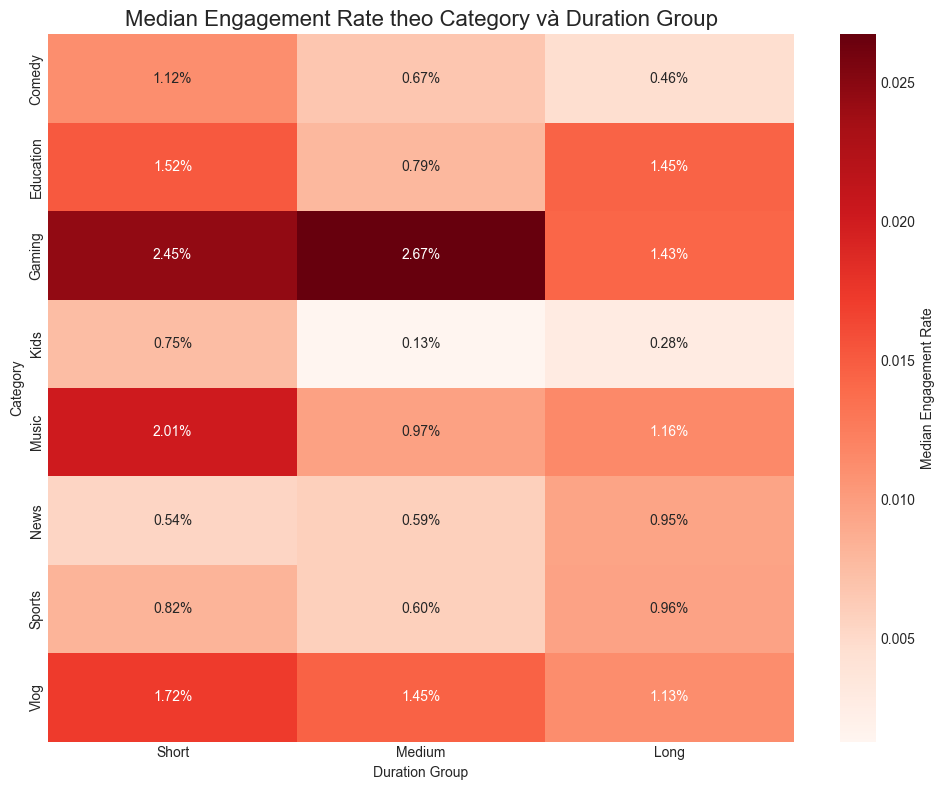

In [5]:
plt.figure(figsize=(10, 8))

duration_order = ['Short', 'Medium', 'Long']
ro2_b1_data = videos[videos['duration_group'].isin(duration_order)].groupby(['channel_category', 'duration_group'])['engagement_rate'].median().unstack()
ro2_b1_data = ro2_b1_data[duration_order]

sns.heatmap(ro2_b1_data, cmap='Reds', annot=True, fmt=".2%", cbar_kws={'label': 'Median Engagement Rate'})
plt.title('Median Engagement Rate theo Category và Duration Group', fontsize=16)
plt.ylabel('Category')
plt.xlabel('Duration Group')
plt.tight_layout()
plt.show()

### B2

<Figure size 1400x700 with 0 Axes>

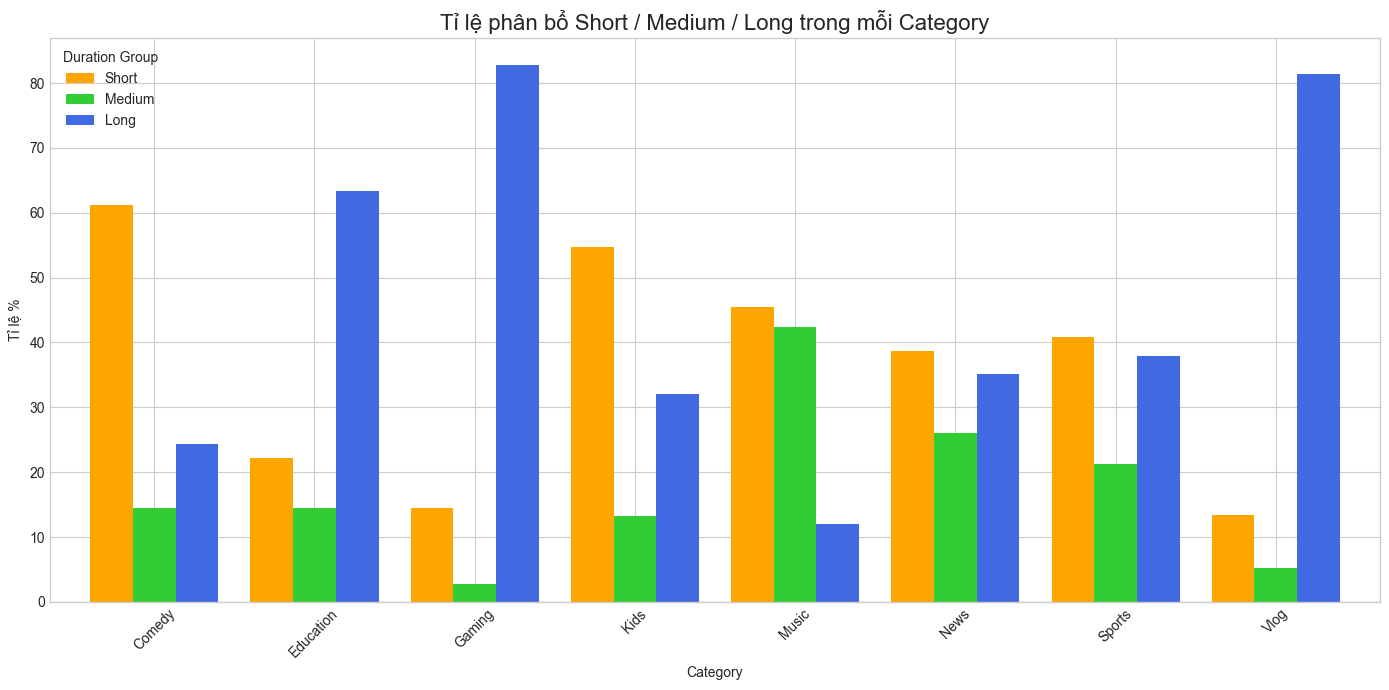

In [6]:
plt.figure(figsize=(14, 7))

ro2_b2_data = videos[videos['duration_group'].isin(duration_order)].groupby(['channel_category', 'duration_group'])['video_id'].count().unstack().fillna(0)
# Normalize theo % của từng category
ro2_b2_data_pct = ro2_b2_data.div(ro2_b2_data.sum(axis=1), axis=0) * 100

ro2_b2_data_pct[duration_order].plot(kind='bar', figsize=(14, 7), color=['orange', 'limegreen', 'royalblue'], width=0.8)
plt.title('Tỉ lệ phân bổ Short / Medium / Long trong mỗi Category', fontsize=16)
plt.xlabel('Category')
plt.ylabel('Tỉ lệ %')
plt.legend(title='Duration Group')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## RO3 — Giờ Vàng Đăng Video (Đổi tên Nghịch lý tương tác trên web)

E2 trên web giữ nguyên

E1 trên web đổi thành 8 đường trendline category dựa trên giá trị video count (giống chart B2 dưới này nhưng thay median view count thành video count)

### B2 (CẦN CHỈNH MEDIA VIEW COUNT THÀNH VIDEO COUNT)

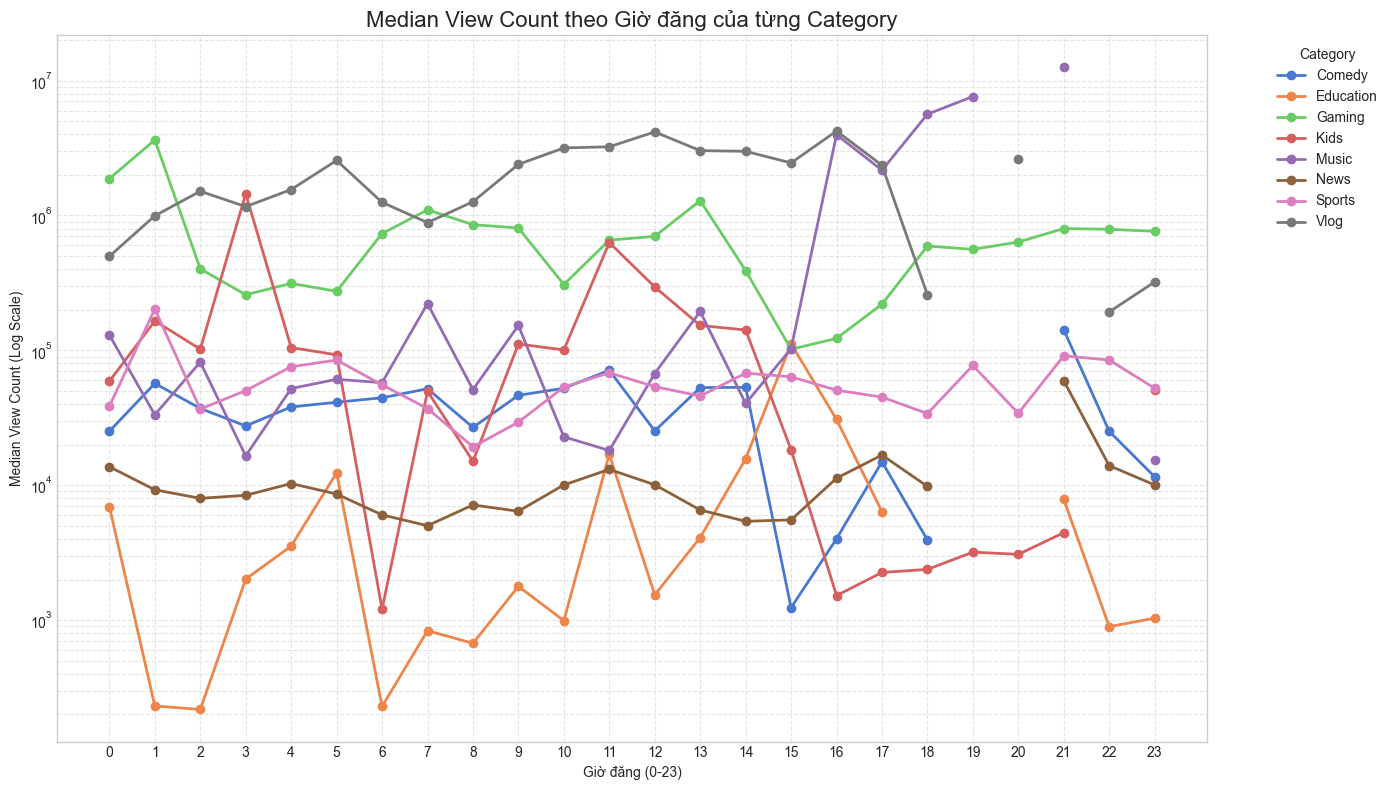

In [8]:
plt.figure(figsize=(14, 8))
ro3_b2_data = videos.groupby(['channel_category', 'hour_posted'])['view_count'].median().unstack().T

for cat in ro3_b2_data.columns:
    plt.plot(ro3_b2_data.index, ro3_b2_data[cat], marker='o', label=cat, linewidth=2)

plt.title('Median View Count theo Giờ đăng của từng Category', fontsize=16)
plt.xlabel('Giờ đăng (0-23)')
plt.ylabel('Median View Count (Log Scale)')
plt.yscale('log')
plt.xticks(range(0, 24))
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

## RO4 — Giải Phẫu Video Viral

### B1

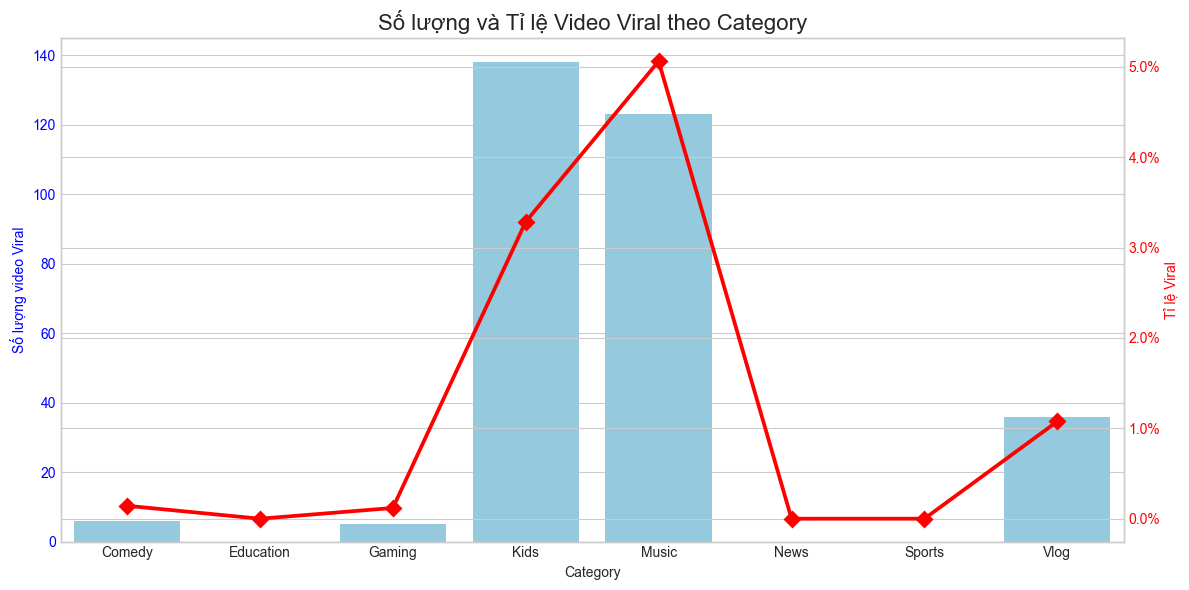

In [9]:
ro4_b1_data = videos.groupby('channel_category')['is_viral'].agg(['sum', 'mean']).reset_index()
ro4_b1_data.rename(columns={'sum': 'Viral Count', 'mean': 'Viral Rate'}, inplace=True)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart (Cột trái) - Số lượng
sns.barplot(x='channel_category', y='Viral Count', data=ro4_b1_data, color='skyblue', ax=ax1)
ax1.set_ylabel('Số lượng video Viral', color='blue')
ax1.set_xlabel('Category')
ax1.tick_params(axis='y', labelcolor='blue')

# Line chart (Cột phải) - Tỉ lệ %
ax2 = ax1.twinx()
sns.pointplot(x='channel_category', y='Viral Rate', data=ro4_b1_data, color='red', markers='D', ax=ax2)
ax2.set_ylabel('Tỉ lệ Viral', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Format trục phải sang %
vals = ax2.get_yticks()
ax2.set_yticklabels(['{:,.1%}'.format(x) for x in vals])

plt.title('Số lượng và Tỉ lệ Video Viral theo Category', fontsize=16)
plt.tight_layout()
plt.show()

### B2

In [3]:
videos = pd.read_csv("data/processed/videos_processed.csv")
videos["is_viral"]      = videos["is_viral"].astype(str).str.lower().map({"true": True, "false": False})
videos["published_at"]  = pd.to_datetime(videos["published_at"])

CAT_ORDER = ["Comedy","Kids","Music","Sports","News","Education","Gaming","Vlog"]
COLORS8   = ["#E45756","#F58518","#72B7B2","#4C78A8","#FF9DA6","#54A24B","#B279A2","#EECA3B"]
FONT      = dict(family="Arial, sans-serif", size=13, color="#111")
TFONT     = dict(family="Arial, sans-serif", size=16, color="#111")

# ── Core logic ─────────────────────────────────────────────
# Với mỗi kênh:
#   - Sort video theo published_at
#   - Với mỗi viral event tại vị trí i:
#       rate_i = số video viral trong [i+1 .. i+10] / 10
#   - channel_momentum_rate = mean(rate_i) qua tất cả viral events của kênh

channel_rates = []

for channel_id, grp in videos.groupby("channel_id"):
    grp = grp.sort_values("published_at").reset_index(drop=True)
    cat = grp["channel_category"].iloc[0]
    viral_positions = grp.index[grp["is_viral"] == True].tolist()

    if not viral_positions:
        continue

    rates_per_event = []
    for vpos in viral_positions:
        next_10 = grp.iloc[vpos+1 : vpos+11]["is_viral"]
        if len(next_10) == 0:
            continue
        rate = next_10.sum() / 10  # luôn chia 10 theo định nghĩa
        rates_per_event.append(rate)

    if rates_per_event:
        channel_rates.append({
            "channel_id":       channel_id,
            "channel_category": cat,
            "momentum_rate":    np.mean(rates_per_event),
            "n_viral_events":   len(rates_per_event),
        })

df_ch = pd.DataFrame(channel_rates)

# ── Baseline: tỉ lệ viral toàn dataset ──
baseline_all = videos["is_viral"].mean() * 100

# ── Boxplot ────────────────────────────────────────────────
fig = go.Figure()

cats_present = [c for c in CAT_ORDER if c in df_ch["channel_category"].unique()]

for cat in cats_present:
    vals  = df_ch[df_ch["channel_category"] == cat]["momentum_rate"].values * 100
    color = COLORS8[CAT_ORDER.index(cat)]
    n_ch  = len(vals)
    fig.add_trace(go.Box(
        y=vals,
        name=f"{cat}<br>(n={n_ch})",
        marker_color=color,
        line_color=color,
        boxmean="sd",       # hiện mean và độ lệch chuẩn
        width=0.5,
        boxpoints="all",    # hiện tất cả điểm dữ liệu
        jitter=0.35,
        pointpos=0,
        marker=dict(size=8, opacity=0.75, color=color),
    ))

# Đường baseline
fig.add_hline(
    y=baseline_all,
    line_dash="dash", line_color="#666", line_width=1.5,
    annotation_text=f"Baseline toàn dataset: {baseline_all:.2f}%",
    annotation_font=dict(size=11, color="#444"),
    annotation_position="top right",
)

fig.update_layout(
    font=FONT,
    plot_bgcolor="white", paper_bgcolor="white",
    width=1000, height=580,
    margin=dict(t=120, b=70, l=80, r=40),
    showlegend=False,
    title=dict(
        text="Viral Momentum Rate per Kênh — Sau 1 Video Viral, 10 Video Tiếp Theo Viral Bao Nhiêu %?<br>"
             "<span style='font-size:13px;font-weight:normal;color:#666'>"
             "Mỗi điểm = 1 kênh | Hộp = IQR | Dấu thập = mean | Đường ngang = baseline dataset</span>",
        font=TFONT,
    ),
    yaxis=dict(
        title="Viral Momentum Rate (%)",
        tickformat=".1f", ticksuffix="%",
        tickfont=dict(size=12), gridcolor="#eee",
    ),
    xaxis=dict(tickfont=dict(size=11)),
)

fig.show()

## RO5 — Quy Mô Kênh vs. Chiến Lược

### B1

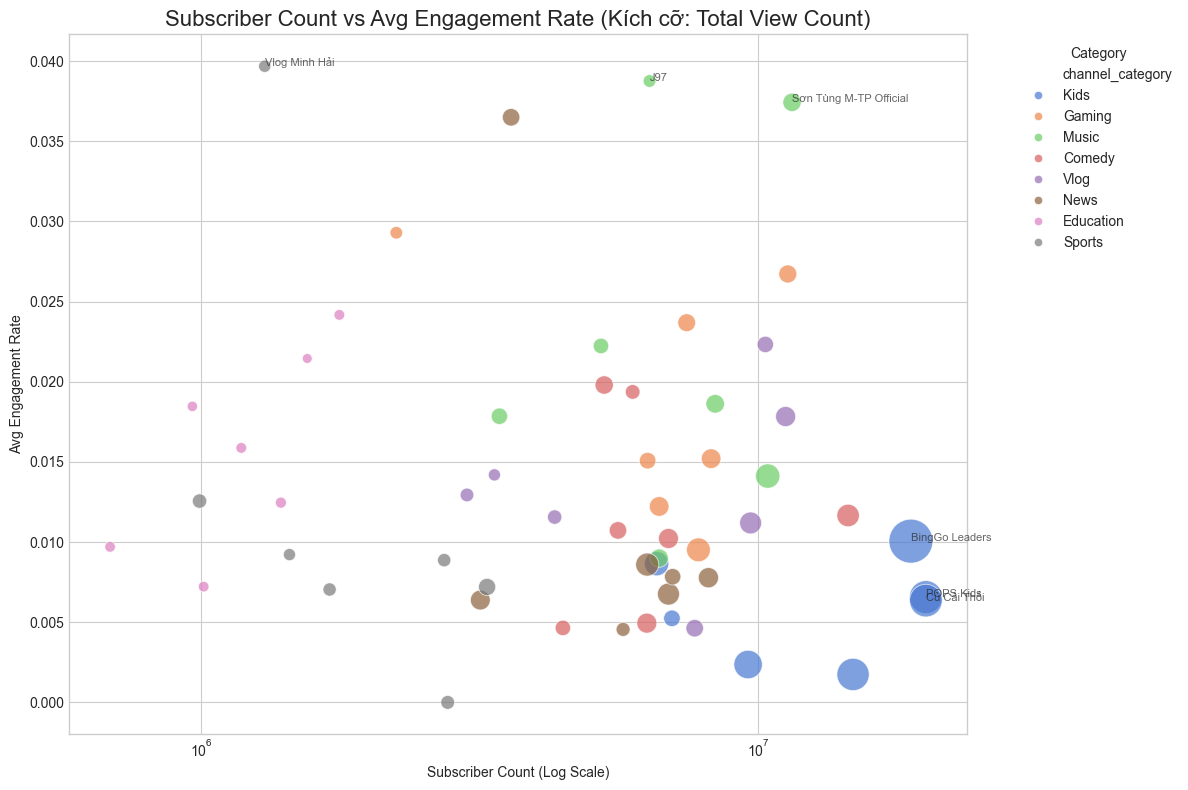

In [4]:
plt.figure(figsize=(12, 8))
# Tăng cường độ kích thước bóng để nhìn rõ
scatter_sizes = channels['total_view_count'].fillna(0) * 1000 + 50

sns.scatterplot(
    data=channels, 
    x='subscriber_count', 
    y='avg_engagement_rate', 
    hue='channel_category', 
    size=scatter_sizes,
    sizes=(50, 1000), 
    alpha=0.7, 
    legend='brief'
)

plt.xscale('log')
plt.title('Subscriber Count vs Avg Engagement Rate (Kích cỡ: Total View Count)', fontsize=16)
plt.xlabel('Subscriber Count (Log Scale)')
plt.ylabel('Avg Engagement Rate')

# Annotate một vài outlier
outliers = channels[(channels['avg_engagement_rate'] > channels['avg_engagement_rate'].quantile(0.95)) | 
                    (channels['subscriber_count'] > channels['subscriber_count'].quantile(0.95))]
for idx, row in outliers.iterrows():
    plt.text(row['subscriber_count'], row['avg_engagement_rate'], row['channel_name'], fontsize=8, alpha=0.7)

# Fix hiển thị Legend
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:9], labels[:9], title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### B2

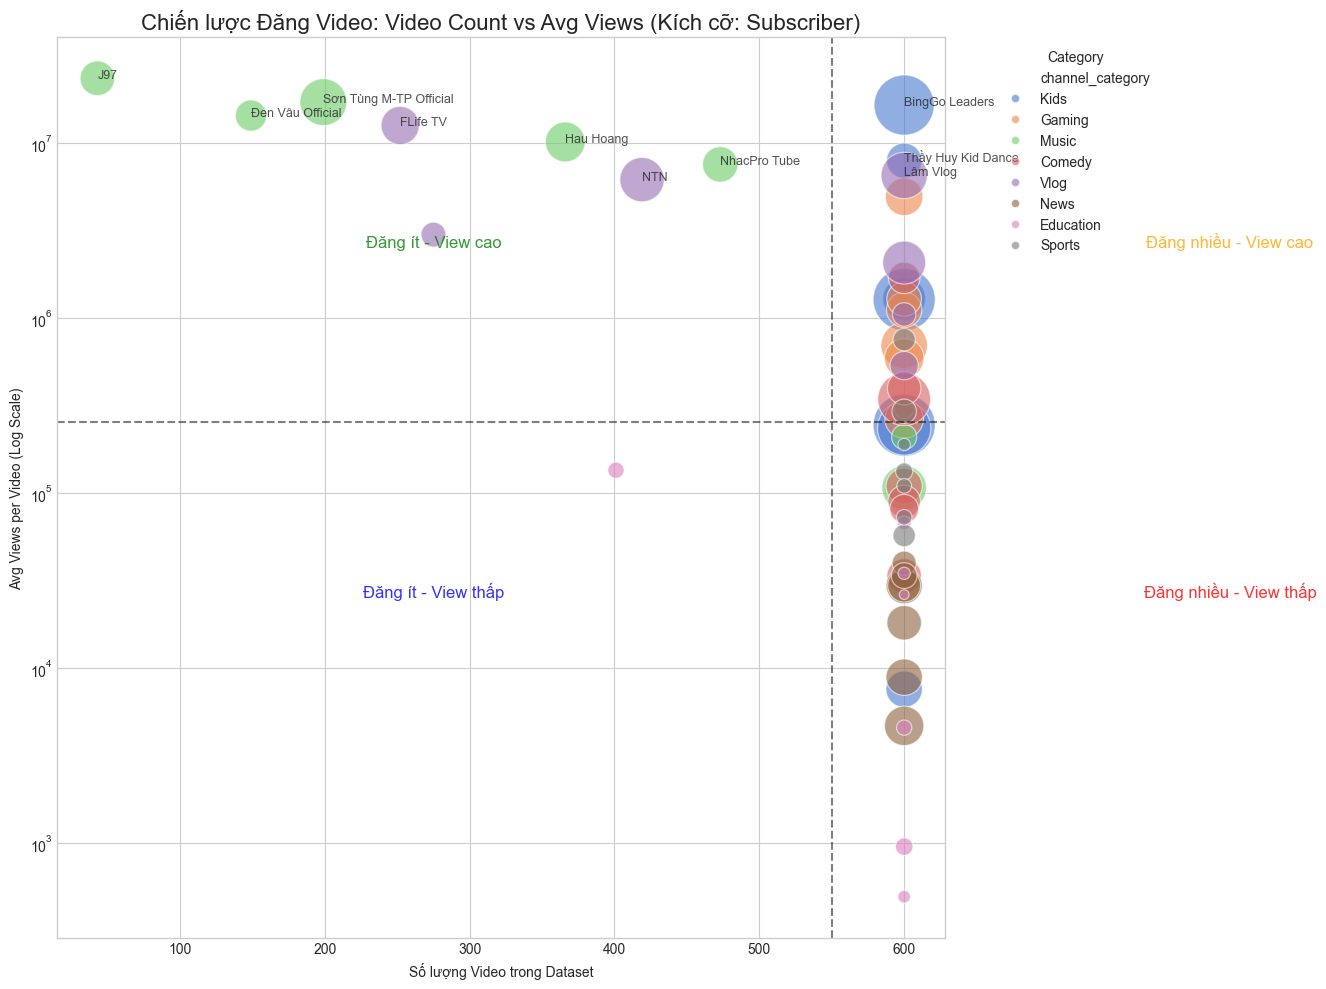

In [5]:
plt.figure(figsize=(14, 10))

sns.scatterplot(
    data=channels,
    x='video_count_dataset',
    y='avg_views_per_video_dataset',
    hue='channel_category',
    size='subscriber_count',
    sizes=(50, 2000),
    alpha=0.6
)

plt.yscale('log')

# Tính toán các đường Quadrant
median_x = channels['video_count_dataset'].median() - 50
median_y = channels['avg_views_per_video_dataset'].median()

plt.axvline(median_x, color='black', linestyle='--', alpha=0.5)
plt.axhline(median_y, color='black', linestyle='--', alpha=0.5)

# Tên 4 góc chiến lược
plt.text(median_x * 0.5, median_y * 10, 'Đăng ít - View cao', fontsize=12, color='green', alpha=0.8, ha='center')
plt.text(median_x * 1.5, median_y * 10, 'Đăng nhiều - View cao', fontsize=12, color='orange', alpha=0.8, ha='center')
plt.text(median_x * 0.5, median_y * 0.1, 'Đăng ít - View thấp', fontsize=12, color='blue', alpha=0.8, ha='center')
plt.text(median_x * 1.5, median_y * 0.1, 'Đăng nhiều - View thấp', fontsize=12, color='red', alpha=0.8, ha='center')

plt.title('Chiến lược Đăng Video: Video Count vs Avg Views (Kích cỡ: Subscriber)', fontsize=16)
plt.xlabel('Số lượng Video trong Dataset')
plt.ylabel('Avg Views per Video (Log Scale)')

# Annotate một số kênh nổi bật ở các rìa
for idx, row in channels.iterrows():
    if row['video_count_dataset'] > 1500 or row['avg_views_per_video_dataset'] > 5000000:
        plt.text(row['video_count_dataset'], row['avg_views_per_video_dataset'], row['channel_name'], fontsize=9, alpha=0.8)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:9], labels[:9], title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()